<!-- Reemplaza USUARIO/REPO por tu repositorio para activar el badge -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USUARIO/REPO/blob/main/02_fundamentos_aprendizaje_automatico.ipynb)

# ¿Qué significa, exactamente, que una máquina aprenda?

**Verificación numérica de los fundamentos del aprendizaje automático clásico**

Luis Javier Rubio Hernández

---

Este cuaderno acompaña al documento del mismo título. Allí cada resultado se enuncia con sus
hipótesis; aquí cada uno se **verifica numéricamente**. No hay dataset externo: todo se genera
de forma determinista, de modo que cualquiera puede ejecutar el cuaderno y obtener exactamente
las mismas cifras que aparecen citadas en el texto.

Lo que se comprueba, en orden:

| | Afirmación | Cómo se verifica |
|---|---|---|
| 1 | El riesgo empírico es insesgado solo si $f$ se fija de antemano | Monte Carlo con 2.000 réplicas |
| 2 | El ECM de la recta de mínimos cuadrados sobre los diez puntos vale 0,0361 | Cálculo directo |
| 3 | Minimizar el ECM equivale a maximizar la verosimilitud con ruido normal | Comparación de ambos óptimos |
| 4 | Un solo atípico mueve la pendiente de 0,695 a 0,374 | Reajuste con un punto añadido |
| 5 | El descenso converge **si y solo si** $0<\alpha<2/\lambda_{\max}$ | Tres tasas alrededor del umbral |
| 6 | Estandarizar lleva el número de condición de 92,11 a 1 | Espectro del hessiano |
| 7 | $\mathbb{E}[(y_0-\hat f)^2] = \sigma^2 + \text{sesgo}^2 + \text{varianza}$ | Identidad verificada por simulación |
| 8 | Con clases desbalanceadas la exactitud puede ser alta y el modelo inútil | Clasificador trivial |
| 9 | Lloyd solo garantiza óptimo local | 50 inicializaciones distintas |
| 10 | El error de entrenamiento no mide calidad | Ajustes polinómicos de grado 1 a 15 |

## 0. Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, optimize

AZUL, GRIS, TEXTO, GRIS_OSC, ROJO = "#0073B1", "#D4D4D4", "#333333", "#767676", "#C0392B"

mpl.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.8),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": GRIS_OSC, "axes.titlecolor": TEXTO,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "xtick.color": GRIS_OSC, "ytick.color": GRIS_OSC,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "grid.color": "#EEEEEE",
})

SEMILLA = 7
np.set_printoptions(precision=4, suppress=True)
print(f"numpy {np.__version__}")

numpy 2.4.4


## 1. Qué significa aprender: riesgo empírico y riesgo esperado

El criterio de éxito no es reproducir los datos con los que se construyó el modelo sino acertar
sobre datos que no participaron de esa construcción. La formulación exacta es:

$$R(f)=\mathbb{E}_{(x,y)\sim\mathcal{P}}\bigl[L(f(x),y)\bigr]
\qquad\qquad
\widehat{R}(f)=\frac{1}{P}\sum_{p=1}^{P}L\bigl(f(x_p),y_p\bigr)$$

La garantía es modesta y precisa: si las observaciones son i.i.d., entonces **para una función
$f$ fijada de antemano** el riesgo empírico es un estimador insesgado del riesgo esperado. La
cláusula en negrita es toda la dificultad de la disciplina. La simulación siguiente la separa en
dos escenarios sobre el mismo proceso generador.

In [2]:
rng = np.random.default_rng(SEMILLA)

# Proceso generador conocido: y = 2 + 3x + ruido normal, sigma = 1
BETA, SIGMA, P, REPLICAS = np.array([2.0, 3.0]), 1.0, 12, 2000

def muestra(n, rng):
    x = rng.uniform(0, 4, n)
    y = BETA[0] + BETA[1]*x + rng.normal(0, SIGMA, n)
    return np.vstack([np.ones(n), x]).T, y

riesgo_verdadero = SIGMA**2          # riesgo esperado de la función verdadera
emp_fija, emp_ajustada, riesgo_ajustada = [], [], []

for _ in range(REPLICAS):
    A, y = muestra(P, rng)
    # (a) f fijada de antemano: la función verdadera
    emp_fija.append(np.mean((A @ BETA - y)**2))
    # (b) f elegida mirando los mismos datos: mínimos cuadrados
    theta = np.linalg.lstsq(A, y, rcond=None)[0]
    emp_ajustada.append(np.mean((A @ theta - y)**2))
    # su riesgo real, medido sobre datos nuevos del mismo proceso
    A2, y2 = muestra(4000, rng)
    riesgo_ajustada.append(np.mean((A2 @ theta - y2)**2))

resumen = pd.DataFrame({
    "Escenario": ["f fijada de antemano", "f ajustada sobre los mismos datos"],
    "Riesgo empírico medio": [np.mean(emp_fija), np.mean(emp_ajustada)],
    "Riesgo esperado": [riesgo_verdadero, np.mean(riesgo_ajustada)],
})
resumen["Sesgo"] = resumen["Riesgo empírico medio"] - resumen["Riesgo esperado"]
resumen.round(4)

,Escenario,Riesgo empírico medio,Riesgo esperado,Sesgo
0,f fijada de antemano,0.9961,1.0000,-0.0039
1,f ajustada sobre los mismos datos,0.8289,1.1958,-0.3670


Con $f$ fijada de antemano el riesgo empírico oscila alrededor del riesgo esperado y su sesgo es
prácticamente nulo. Cuando $f$ se elige mirando los mismos datos que luego la evalúan, el error
de entrenamiento queda **sistemáticamente por debajo** del riesgo real. La teoría predice
exactamente cuánto: para regresión lineal con $d$ parámetros,
$\mathbb{E}[\widehat{R}]=\sigma^2(P-d)/P$, y el riesgo esperado del ajuste es
$\sigma^2(1+d/P)$.

In [3]:
d = 2
print(f"E[riesgo empírico] teórico  = {SIGMA**2*(P-d)/P:.4f}   "
      f"simulado = {np.mean(emp_ajustada):.4f}")
print(f"Riesgo esperado teórico     = {SIGMA**2*(1+d/P):.4f}   "
      f"simulado = {np.mean(riesgo_ajustada):.4f}")
print("\nEl error de entrenamiento no es un estimador conservador: "
      "es un optimista sistemático.")

E[riesgo empírico] teórico  = 0.8333   simulado = 0.8289
Riesgo esperado teórico     = 1.1667   simulado = 1.1958

El error de entrenamiento no es un estimador conservador: es un optimista sistemático.


## 2. Las cuatro piezas sobre un problema mínimo

Los diez puntos que aparecen en todas las figuras del documento. Son sintéticos y están escritos
de forma explícita, no generados al azar: eso hace que cada cifra citada sea verificable.

In [4]:
X = np.array([1.0, 1.6, 2.1, 2.6, 3.0, 3.6, 4.1, 4.6, 5.2, 5.8])
Y = np.array([1.4, 1.9, 2.0, 2.9, 2.6, 3.4, 3.3, 4.1, 4.4, 4.7])
P10 = X.size

A = np.vstack([np.ones(P10), X]).T          # matriz de diseño, con columna de unos
def costo(theta, A=A, y=Y):                 # tercera pieza: el ECM
    return np.mean((A @ theta - y)**2)

theta_est = np.linalg.lstsq(A, Y, rcond=None)[0]   # b*, w*
b_est, w_est = theta_est

print(f"Matriz de diseño X : {A.shape[0]} x {A.shape[1]}")
print(f"Intercepto b*      : {b_est:.4f}")
print(f"Pendiente  w*      : {w_est:.4f}")
print(f"ECM                : {costo(theta_est):.4f}")

Matriz de diseño X : 10 x 2
Intercepto b*      : 0.7349
Pendiente  w*      : 0.6950
ECM                : 0.0361


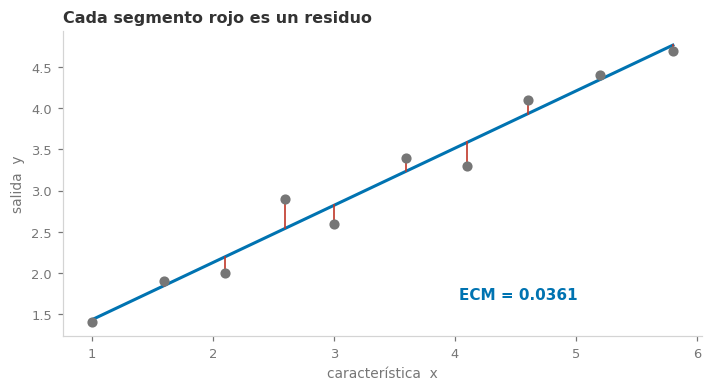

In [5]:
residuos = A @ theta_est - Y
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(X, A @ theta_est, color=AZUL, lw=2, zorder=1)
ax.scatter(X, Y, color=GRIS_OSC, s=32, zorder=3)
for xi, yi, ri in zip(X, Y, residuos):
    ax.plot([xi, xi], [yi, yi + ri], color=ROJO, lw=1.1, zorder=2)
ax.set_xlabel("característica  x"); ax.set_ylabel("salida  y")
ax.set_title("Cada segmento rojo es un residuo")
ax.text(0.62, 0.12, f"ECM = {costo(theta_est):.4f}", transform=ax.transAxes,
        color=AZUL, fontsize=10, fontweight="bold")
plt.show()

### 2.1 Por qué el cuadrado y no otra pérdida

La cuarta razón del documento es estadística y se puede comprobar: si
$y_p=b+x_p^\top w+\varepsilon_p$ con $\varepsilon_p\sim\mathcal{N}(0,\sigma^2)$ independientes,
entonces maximizar la verosimilitud **es** minimizar la suma de cuadrados. No es una analogía:
los dos problemas tienen el mismo argumento óptimo.

In [6]:
def neg_log_verosimilitud(params):
    b, w, log_s = params
    s2 = np.exp(2*log_s)
    r = b + w*X - Y
    return 0.5*P10*np.log(2*np.pi*s2) + np.sum(r**2)/(2*s2)

opt = optimize.minimize(neg_log_verosimilitud, x0=[0., 0., 0.], method="Nelder-Mead",
                        options={"xatol": 1e-10, "fatol": 1e-12, "maxiter": 20000})
b_mv, w_mv = opt.x[0], opt.x[1]

print(f"Mínimos cuadrados       : b = {b_est:.6f}, w = {w_est:.6f}")
print(f"Máxima verosimilitud    : b = {b_mv:.6f}, w = {w_mv:.6f}")
print(f"Diferencia absoluta máx.: {max(abs(b_mv-b_est), abs(w_mv-w_est)):.2e}")
print(f"\nVarianza estimada por MV: {np.exp(2*opt.x[2]):.6f}  "
      f"(coincide con el ECM: {costo(theta_est):.6f})")

Mínimos cuadrados       : b = 0.734887, w = 0.694974
Máxima verosimilitud    : b = 0.734887, w = 0.694974
Diferencia absoluta máx.: 9.92e-09

Varianza estimada por MV: 0.036079  (coincide con el ECM: 0.036079)


### 2.2 El precio del cuadrado

Elevar al cuadrado hace que una sola observación anómala pese enormemente, porque su
contribución crece con el cuadrado de la distancia. Basta añadir un punto a los diez originales.

In [7]:
Xa, Ya = np.append(X, 5.9), np.append(Y, 0.9)
Aa = np.vstack([np.ones(Xa.size), Xa]).T
b_a, w_a = np.linalg.lstsq(Aa, Ya, rcond=None)[0]

print(f"Sin el atípico : b = {b_est:.4f}, w = {w_est:.4f}")
print(f"Con el atípico : b = {b_a:.4f}, w = {w_a:.4f}")
print(f"La pendiente cae un {100*(w_est-w_a)/w_est:.1f} % por un solo dato de once.")

Sin el atípico : b = 0.7349, w = 0.6950
Con el atípico : b = 1.5298, w = 0.3740
La pendiente cae un 46.2 % por un solo dato de once.


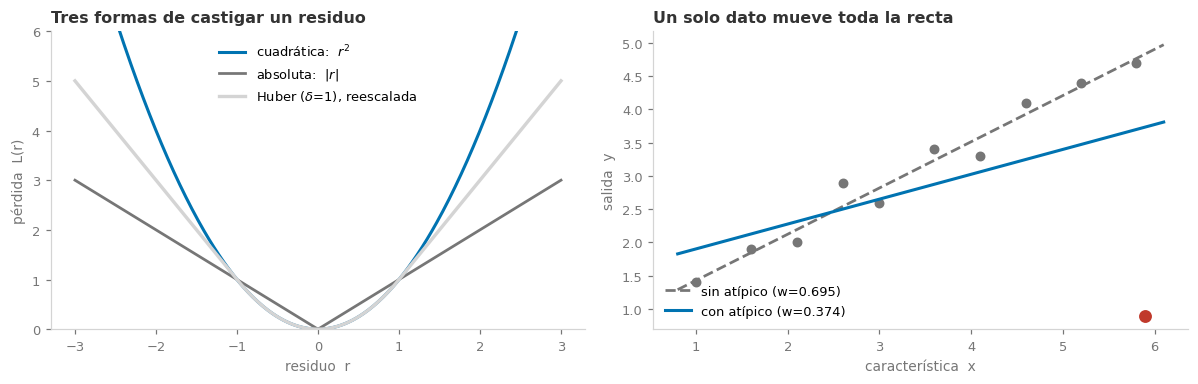

In [8]:
r = np.linspace(-3, 3, 400)
delta = 1.0
huber = np.where(np.abs(r) <= delta, .5*r**2, delta*(np.abs(r) - .5*delta))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].plot(r, r**2, color=AZUL, lw=2, label="cuadrática:  $r^2$")
ax[0].plot(r, np.abs(r), color=GRIS_OSC, lw=1.8, label="absoluta:  $|r|$")
ax[0].plot(r, 2*huber, color=GRIS, lw=2.2, label="Huber ($\\delta$=1), reescalada")
ax[0].set_ylim(0, 6); ax[0].set_xlabel("residuo  r"); ax[0].set_ylabel("pérdida  L(r)")
ax[0].set_title("Tres formas de castigar un residuo"); ax[0].legend()

ax[1].scatter(X, Y, color=GRIS_OSC, s=30)
ax[1].scatter([5.9], [0.9], color=ROJO, s=55, zorder=4)
rejilla = np.linspace(.8, 6.1, 50)
ax[1].plot(rejilla, b_est + w_est*rejilla, color=GRIS_OSC, lw=1.8, ls="--",
           label=f"sin atípico (w={w_est:.3f})")
ax[1].plot(rejilla, b_a + w_a*rejilla, color=AZUL, lw=2,
           label=f"con atípico (w={w_a:.3f})")
ax[1].set_xlabel("característica  x"); ax[1].set_ylabel("salida  y")
ax[1].set_title("Un solo dato mueve toda la recta"); ax[1].legend(loc="lower left")

fig.tight_layout(); plt.show()

## 3. El algoritmo: descenso del gradiente

Para el ECM con modelo lineal el gradiente y el hessiano son exactos:

$$\nabla g(\theta)=\frac{2}{P}\mathbf{X}^\top(\mathbf{X}\theta-y),
\qquad \nabla^2 g(\theta)=\frac{2}{P}\mathbf{X}^\top\mathbf{X}\succeq 0$$

El hessiano es semidefinido positivo, y eso —ni más ni menos— demuestra que el costo es convexo.
Para un costo cuadrático con hessiano definido positivo el método converge **si y solo si**
$0<\alpha<2/\lambda_{\max}$.

In [9]:
def gradiente(theta, A=A, y=Y):
    return 2/A.shape[0] * A.T @ (A @ theta - y)

H = 2/P10 * A.T @ A
valores_propios = np.linalg.eigvalsh(H)
L_const, kappa = valores_propios.max(), valores_propios.max()/valores_propios.min()

print("Hessiano:\n", H)
print(f"\nValores propios      : {valores_propios}")
print(f"¿Definido positivo?  : {bool((valores_propios > 0).all())}  -> el costo es convexo")
print(f"L = lambda_max       : {L_const:.2f}")
print(f"Umbral de divergencia: 2/L = {2/L_const:.4f}")
print(f"Número de condición  : {kappa:.2f}")

Hessiano:
 [[ 2.     6.72 ]
 [ 6.72  27.068]]

Valores propios      : [ 0.3122 28.7558]
¿Definido positivo?  : True  -> el costo es convexo
L = lambda_max       : 28.76
Umbral de divergencia: 2/L = 0.0696
Número de condición  : 92.11


In [10]:
def descender(alfa, iteraciones=60, theta0=np.array([2.0, 0.2])):
    th, camino = theta0.copy(), [theta0.copy()]
    for _ in range(iteraciones):
        th = th - alfa*gradiente(th)
        camino.append(th.copy())
    return np.array(camino)

g_optimo = costo(theta_est)
tasas = {"0.06/L (demasiado pequeño)": .06/L_const,
         "1/L (adecuado)": 1/L_const,
         "2.05/L (diverge)": 2.05/L_const}

for nombre, a in tasas.items():
    camino = descender(a)
    brecha = np.array([costo(t) - g_optimo for t in camino])
    print(f"{nombre:<28} alfa = {a:.4f}   "
          f"brecha inicial = {brecha[0]:.3e}   brecha tras 40 iter = {brecha[40]:.3e}")

# La tasa de divergencia es exacta y se puede predecir sin iterar:
# en la dirección del valor propio máximo el error se multiplica por |1 - alfa*L|
camino_div = descender(2.05/L_const)
factor = (costo(camino_div[40]) - g_optimo) / (costo(camino_div[0]) - g_optimo)
razon = abs(1 - (2.05/L_const)*L_const)
print(f"\nCon alfa = 2.05/L el error se multiplica por |1 - alfa*L| = {razon:.2f} "
      f"por iteración,")
print(f"y el costo, que es cuadrático en el error, por {razon**2:.4f}.")
print(f"Cota asintótica a 40 iteraciones: factor {razon**80:.2f}   "
      f"| observado: {factor:.2f}")
print("(El observado es menor porque el error inicial no está alineado con el "
      "vector propio\ndominante; la razón asintótica se alcanza al cabo de "
      "varias iteraciones.)")
print(f"Son {np.log10(factor):.1f} órdenes de magnitud. Para superar diez órdenes en "
      f"40 iteraciones haría falta")
print(f"alfa > {(1 + 10**(10/80))/L_const*L_const:.2f}/L, no 2.05/L: "
      f"la divergencia es geométrica, pero su razón depende del exceso sobre el umbral.")

0.06/L (demasiado pequeño)   alfa = 0.0021   brecha inicial = 7.083e-01   brecha tras 40 iter = 2.721e-01
1/L (adecuado)               alfa = 0.0348   brecha inicial = 7.083e-01   brecha tras 40 iter = 1.184e-01
2.05/L (diverge)             alfa = 0.0713   brecha inicial = 7.083e-01   brecha tras 40 iter = 2.110e+01

Con alfa = 2.05/L el error se multiplica por |1 - alfa*L| = 1.05 por iteración,
y el costo, que es cuadrático en el error, por 1.1025.
Cota asintótica a 40 iteraciones: factor 49.56   | observado: 29.79
(El observado es menor porque el error inicial no está alineado con el vector propio
dominante; la razón asintótica se alcanza al cabo de varias iteraciones.)
Son 1.5 órdenes de magnitud. Para superar diez órdenes en 40 iteraciones haría falta
alfa > 2.33/L, no 2.05/L: la divergencia es geométrica, pero su razón depende del exceso sobre el umbral.


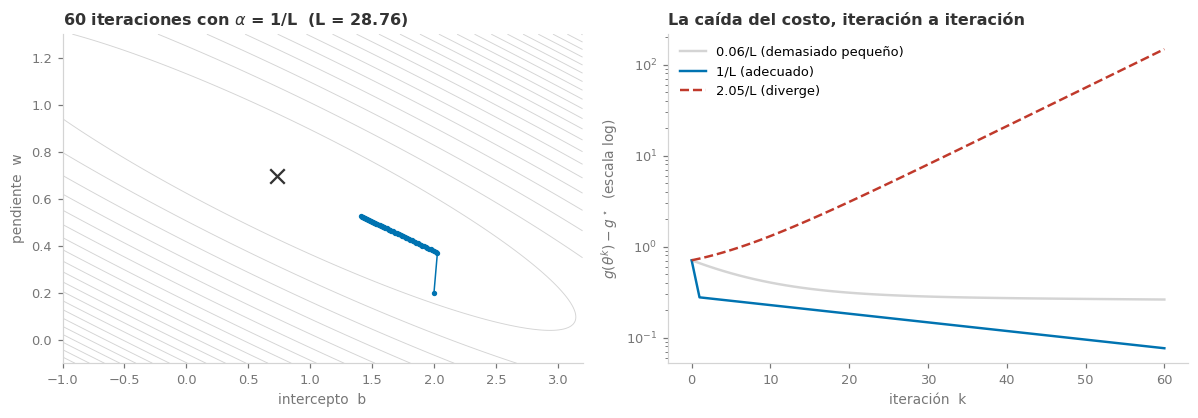

In [11]:
b_malla = np.linspace(-1, 3.2, 220)
w_malla = np.linspace(-.1, 1.3, 220)
BB, WW = np.meshgrid(b_malla, w_malla)
ZZ = np.array([[costo(np.array([b, w])) for b in b_malla] for w in w_malla])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))

ax[0].contour(BB, WW, ZZ, levels=25, colors=GRIS, linewidths=.6)
camino = descender(1/L_const)
ax[0].plot(camino[:, 0], camino[:, 1], "-o", color=AZUL, ms=2.5, lw=1)
ax[0].scatter(*theta_est, marker="x", s=90, color=TEXTO, zorder=5)
ax[0].set_xlabel("intercepto  b"); ax[0].set_ylabel("pendiente  w")
ax[0].set_title(f"60 iteraciones con $\\alpha$ = 1/L  (L = {L_const:.2f})")

for (nombre, a), color, estilo in zip(tasas.items(), [GRIS, AZUL, ROJO], ["-", "-", "--"]):
    brecha = np.array([max(costo(t) - g_optimo, 1e-16) for t in descender(a)])
    ax[1].semilogy(brecha, estilo, color=color, lw=1.6, label=nombre)
ax[1].set_xlabel("iteración  k"); ax[1].set_ylabel("$g(\\theta^k) - g^\\star$  (escala log)")
ax[1].set_title("La caída del costo, iteración a iteración"); ax[1].legend()

fig.tight_layout(); plt.show()

Pasar el umbral no significa converger más despacio: significa alejarse del mínimo en cada
iteración. Es un cambio cualitativo, no de grado.

### 3.1 El escalado no es cosmético

Centrar y escalar es un **cambio de parametrización, no de modelo**: la transformación es afín e
invertible y el modelo incluye término independiente, de modo que la recta ajustada, deshecho el
cambio, es idéntica. Lo único que cambia es la geometría que ve el algoritmo, y cambia mucho.

In [12]:
Z = (X - X.mean())/X.std(ddof=0)
Az = np.vstack([np.ones(P10), Z]).T
Hz = 2/P10 * Az.T @ Az
ev_z = np.linalg.eigvalsh(Hz)
theta_z = np.linalg.lstsq(Az, Y, rcond=None)[0]

# La recta es la misma una vez deshecho el cambio de variable
w_orig = theta_z[1]/X.std(ddof=0)
b_orig = theta_z[0] - theta_z[1]*X.mean()/X.std(ddof=0)
print(f"Recta recuperada desde la parametrización estandarizada: "
      f"b = {b_orig:.6f}, w = {w_orig:.6f}")
print(f"Recta original                                        : "
      f"b = {b_est:.6f}, w = {w_est:.6f}")

def iteraciones_hasta(A_, y_, tol=1e-8, maxit=20000):
    Hloc = 2/A_.shape[0] * A_.T @ A_
    a = 1/np.linalg.eigvalsh(Hloc).max()
    th_opt = np.linalg.lstsq(A_, y_, rcond=None)[0]
    g_opt = np.mean((A_ @ th_opt - y_)**2)
    th = np.zeros(2)
    for k in range(1, maxit+1):
        th = th - a * (2/A_.shape[0] * A_.T @ (A_ @ th - y_))
        if (np.mean((A_ @ th - y_)**2) - g_opt) <= tol*max(g_opt, 1e-12):
            return k
    return None

print(f"\nSin escalar    : kappa = {kappa:.2f}   "
      f"iteraciones hasta brecha relativa 1e-8: {iteraciones_hasta(A, Y)}")
print(f"Estandarizadas : kappa = {ev_z.max()/ev_z.min():.4f}   "
      f"iteraciones hasta brecha relativa 1e-8: {iteraciones_hasta(Az, Y)}")

Recta recuperada desde la parametrización estandarizada: b = 0.734887, w = 0.694974
Recta original                                        : b = 0.734887, w = 0.694974

Sin escalar    : kappa = 92.11   iteraciones hasta brecha relativa 1e-8: 855
Estandarizadas : kappa = 1.0000   iteraciones hasta brecha relativa 1e-8: 1


Con $\kappa=1$ las curvas de nivel son circunferencias, el gradiente apunta directamente al
mínimo y el método llega en un solo paso. Cuando alguien reporta que "el descenso del gradiente
no converge", muchas veces el problema no está en el algoritmo ni en la tasa, sino en que las
características se midieron en escalas incomparables.

## 4. Sesgo y varianza: una identidad, no una aproximación

$$\mathbb{E}\bigl[(y_0-\hat f(x_0))^2\bigr]
=\underbrace{\sigma^2}_{\text{irreducible}}
+\underbrace{[\text{Sesgo}(\hat f(x_0))]^2}_{\text{rigidez}}
+\underbrace{\text{Var}(\hat f(x_0))}_{\text{inestabilidad}}$$

La simulación reajusta el modelo sobre muchas muestras del mismo proceso y evalúa siempre en el
mismo punto $x_0$. Con eso los tres términos se estiman por separado y se comparan con el error
total observado.

In [13]:
rng = np.random.default_rng(SEMILLA)
f_verdadera = lambda x: np.sin(1.5*x) + .35*x
SIGMA_R, N_ENTR, X0, REPS = .30, 25, 2.4, 3000

pred = {g: [] for g in (1, 3, 9)}
for _ in range(REPS):
    x = rng.uniform(0, 5, N_ENTR)
    y = f_verdadera(x) + rng.normal(0, SIGMA_R, N_ENTR)
    for g in pred:
        pred[g].append(np.polyval(np.polyfit(x, y, g), X0))

filas = []
for g, v in pred.items():
    v = np.array(v)
    sesgo2 = (v.mean() - f_verdadera(X0))**2
    var = v.var()
    filas.append({"Grado": g, "Ruido irreducible": SIGMA_R**2, "Sesgo²": sesgo2,
                  "Varianza": var, "Suma": SIGMA_R**2 + sesgo2 + var,
                  "Error total simulado":
                      np.mean((f_verdadera(X0) + rng.normal(0, SIGMA_R, REPS) - v)**2)})

pd.DataFrame(filas).round(4)

,Grado,Ruido irreducible,Sesgo²,Varianza,Suma,Error total simulado
0,1,0.09,0.2819,0.0205,0.3924,0.3805
1,3,0.09,0.0320,0.0144,0.1364,0.1337
2,9,0.09,0.0000,0.0417,0.1317,0.1278


La suma de los tres términos reproduce el error total simulado en los tres grados, con
diferencias del orden del error de Monte Carlo. Y el patrón es el del intercambio: al pasar del grado 1 al 9 el sesgo cae y la varianza sube. Reducir uno
suele aumentar el otro; ese intercambio es el problema central del oficio.

## 5. Clasificación: por qué la exactitud engaña

El ejemplo del documento, comprobado: una enfermedad con prevalencia del 1 % y un clasificador
que responde "sano" a todo el mundo, sin mirar nada.

In [14]:
rng = np.random.default_rng(SEMILLA)
n, prevalencia = 1000, .01
verdad = (rng.random(n) < prevalencia).astype(int)
prediccion = np.zeros(n, dtype=int)          # el clasificador trivial

VP = int(((prediccion == 1) & (verdad == 1)).sum())
FP = int(((prediccion == 1) & (verdad == 0)).sum())
FN = int(((prediccion == 0) & (verdad == 1)).sum())
VN = int(((prediccion == 0) & (verdad == 0)).sum())

exactitud = (VP + VN)/n
sensibilidad = VP/(VP + FN) if (VP + FN) else float("nan")
precision = VP/(VP + FP) if (VP + FP) else float("nan")

print(pd.DataFrame([[VP, FN], [FP, VN]],
                   index=["es positivo", "es negativo"],
                   columns=["predice positivo", "predice negativo"]).to_string())
print(f"\nExactitud    : {exactitud:.3f}")
print(f"Sensibilidad : {sensibilidad:.3f}   (no detectó a ninguno de los {VP+FN} enfermos)")
print(f"Precisión    : {precision}   (indefinida: el denominador VP+FP es cero)")
print("\nUn modelo inútil con una cifra excelente.")

             predice positivo  predice negativo
es positivo                 0                 8
es negativo                 0               992

Exactitud    : 0.992
Sensibilidad : 0.000   (no detectó a ninguno de los 8 enfermos)
Precisión    : nan   (indefinida: el denominador VP+FP es cero)

Un modelo inútil con una cifra excelente.


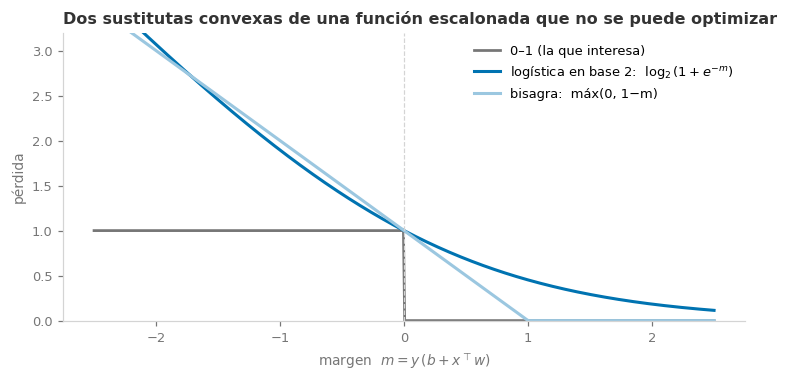

¿bisagra >= 0-1 en todo el rango?                   True
¿logística con logaritmo natural >= 0-1?            False   (en m=0 vale 0.6931 < 1)
¿logística en base 2, log2(1+e^-m) >= 0-1?          True

La logística acota la 0-1 solo tras reescalarla por 1/ln 2. Con logaritmo natural
no es una cota superior: en m = 0 queda por debajo. La constante no cambia el
argumento mínimo, pero el enunciado 'la acota por arriba' exige decir en qué base.


In [15]:
m = np.linspace(-2.5, 2.5, 500)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(m, (m <= 0).astype(float), color=GRIS_OSC, lw=1.8, label="0–1 (la que interesa)")
ax.plot(m, np.log2(1 + np.exp(-m)), color=AZUL, lw=2,
        label="logística en base 2:  $\\log_2(1+e^{-m})$")
ax.plot(m, np.maximum(0, 1 - m), color="#9BC7E0", lw=2, label="bisagra:  máx(0, 1−m)")
ax.axvline(0, color=GRIS, lw=.8, ls="--")
ax.set_xlabel("margen  $m = y\\,(b + x^{\\top}w)$"); ax.set_ylabel("pérdida")
ax.set_title("Dos sustitutas convexas de una función escalonada que no se puede optimizar")
ax.set_ylim(0, 3.2)
ax.legend(); plt.show()

# Verificación de la cota superior, con una precisión que suele omitirse
cero_uno = (m <= 0).astype(float)
print("¿bisagra >= 0-1 en todo el rango?                  ",
      bool((np.maximum(0, 1-m) >= cero_uno).all()))
print("¿logística con logaritmo natural >= 0-1?           ",
      bool((np.log(1+np.exp(-m)) >= cero_uno).all()),
      f"  (en m=0 vale {np.log(2):.4f} < 1)")
print("¿logística en base 2, log2(1+e^-m) >= 0-1?         ",
      bool((np.log2(1+np.exp(-m)) >= cero_uno).all()))
print("\nLa logística acota la 0-1 solo tras reescalarla por 1/ln 2. "
      "Con logaritmo natural\nno es una cota superior: en m = 0 queda por debajo. "
      "La constante no cambia el\nargumento mínimo, pero el enunciado 'la acota por arriba' "
      "exige decir en qué base.")

## 6. No supervisado: k-medias y la honestidad sobre sus límites

Dos afirmaciones que suelen omitirse y que conviene verificar: el algoritmo de Lloyd garantiza
únicamente un óptimo local, y el resultado depende de la inicialización.

In [16]:
rng = np.random.default_rng(SEMILLA)
centros = np.array([[-1.6, 1.4], [1.8, 1.6], [.2, -1.7]])
tam = [21, 21, 20]
nube = np.vstack([c + .55*rng.normal(size=(t, 2)) for c, t in zip(centros, tam)])
print(f"Nube: {nube.shape[0]} puntos generados con {len(centros)} centros")

def lloyd(datos, k, rng, max_iter=100):
    mu = datos[rng.choice(datos.shape[0], k, replace=False)]
    for _ in range(max_iter):
        d = ((datos[:, None, :] - mu[None, :, :])**2).sum(axis=2)
        etiq = d.argmin(axis=1)
        nuevo = np.array([datos[etiq == j].mean(axis=0) if (etiq == j).any() else mu[j]
                          for j in range(k)])
        if np.allclose(nuevo, mu):
            break
        mu = nuevo
    inercia = ((datos - mu[etiq])**2).sum()
    return etiq, mu, inercia

etiq, mu, inercia = lloyd(nube, 3, np.random.default_rng(SEMILLA))
print(f"Inercia de esta ejecución: {inercia:.4f}")

inercias = [lloyd(nube, 3, np.random.default_rng(s))[2] for s in range(50)]
inercias = np.round(inercias, 6)
print(f"\n50 inicializaciones distintas -> {len(set(inercias))} óptimos locales diferentes")
print(f"Mejor: {min(inercias):.4f}   Peor: {max(inercias):.4f}   "
      f"Diferencia: {100*(max(inercias)-min(inercias))/min(inercias):.1f} %")

Nube: 62 puntos generados con 3 centros
Inercia de esta ejecución: 26.6022

50 inicializaciones distintas -> 5 óptimos locales diferentes
Mejor: 26.6022   Peor: 171.4380   Diferencia: 544.4 %


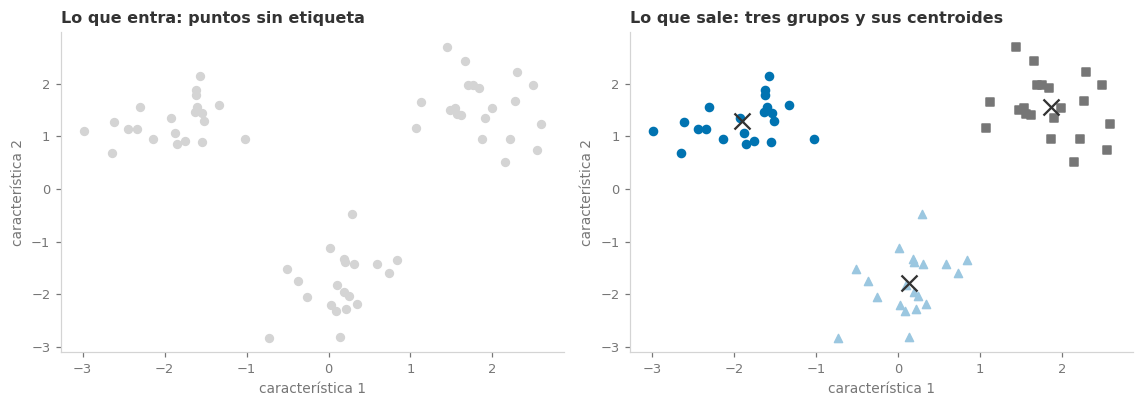

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8))
ax[0].scatter(nube[:, 0], nube[:, 1], color=GRIS, s=26)
ax[0].set_title("Lo que entra: puntos sin etiqueta")

marcas, colores = ["o", "s", "^"], [AZUL, GRIS_OSC, "#9BC7E0"]
for j in range(3):
    p = nube[etiq == j]
    ax[1].scatter(p[:, 0], p[:, 1], marker=marcas[j], color=colores[j], s=28)
    ax[1].scatter(*mu[j], marker="x", s=110, color=TEXTO, zorder=5)
ax[1].set_title("Lo que sale: tres grupos y sus centroides")

for a in ax:
    a.set_xlabel("característica 1"); a.set_ylabel("característica 2")
fig.tight_layout(); plt.show()

Sin etiqueta no hay error que medir, y sin error que medir la evaluación deja de ser una
verificación y pasa a ser un juicio. Eso no invalida el método: obliga a declarar el criterio.

## 7. Cuando el modelo falla: el error de entrenamiento no mide calidad

La lección final del documento, y la que se puede demostrar en diez líneas: el error de
entrenamiento se puede llevar tan cerca de cero como se quiera agregando parámetros, y hacerlo
empeora el modelo.

In [18]:
rng = np.random.default_rng(SEMILLA)
N_PUNTOS, SIGMA_P = 20, .25
x_tr = np.sort(rng.uniform(0, 1, N_PUNTOS))
f_seno = lambda x: np.sin(2*np.pi*x)
y_tr = f_seno(x_tr) + rng.normal(0, SIGMA_P, N_PUNTOS)

x_te = np.sort(rng.uniform(0, 1, 500))
y_te = f_seno(x_te) + rng.normal(0, SIGMA_P, 500)

grados = range(1, 16)
recm = lambda y, yh: float(np.sqrt(np.mean((y - yh)**2)))
err_tr, err_te = [], []
for g in grados:
    c = np.polyfit(x_tr, y_tr, g)
    err_tr.append(recm(y_tr, np.polyval(c, x_tr)))
    err_te.append(recm(y_te, np.polyval(c, x_te)))

mejor = list(grados)[int(np.argmin(err_te))]
print(f"Grado con menor error en prueba : {mejor}")
print(f"Grado con menor error en entren.: {list(grados)[int(np.argmin(err_tr))]}")
print(f"\nGrado {mejor:>2}: RECM entren. {err_tr[mejor-1]:.3f} | prueba {err_te[mejor-1]:.3f} | "
      f"brecha {err_te[mejor-1]-err_tr[mejor-1]:+.3f}")
print(f"Grado 15: RECM entren. {err_tr[-1]:.3f} | prueba {err_te[-1]:.3f} | "
      f"brecha {err_te[-1]-err_tr[-1]:+.3f}")

Grado con menor error en prueba : 6
Grado con menor error en entren.: 15

Grado  6: RECM entren. 0.181 | prueba 0.273 | brecha +0.093
Grado 15: RECM entren. 0.090 | prueba 1755.286 | brecha +1755.196


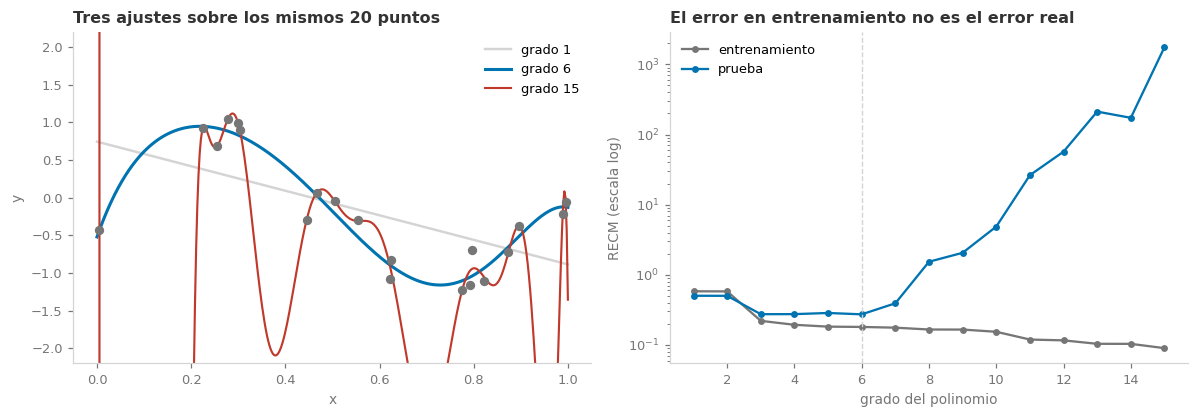

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))

rejilla = np.linspace(0, 1, 400)
for g, color, lw in [(1, GRIS, 1.6), (mejor, AZUL, 2), (15, ROJO, 1.4)]:
    ax[0].plot(rejilla, np.polyval(np.polyfit(x_tr, y_tr, g), rejilla),
               color=color, lw=lw, label=f"grado {g}")
ax[0].scatter(x_tr, y_tr, color=GRIS_OSC, s=26, zorder=4)
ax[0].set_ylim(-2.2, 2.2); ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
ax[0].set_title(f"Tres ajustes sobre los mismos {N_PUNTOS} puntos"); ax[0].legend()

ax[1].semilogy(list(grados), err_tr, "-o", color=GRIS_OSC, ms=3.5, label="entrenamiento")
ax[1].semilogy(list(grados), err_te, "-o", color=AZUL, ms=3.5, label="prueba")
ax[1].axvline(mejor, color=GRIS, ls="--", lw=.9)
ax[1].set_xlabel("grado del polinomio"); ax[1].set_ylabel("RECM (escala log)")
ax[1].set_title("El error en entrenamiento no es el error real"); ax[1].legend()

fig.tight_layout(); plt.show()

El error de entrenamiento no deja de bajar mientras el de prueba se dispara. Lo que delata el
sobreajuste no es el valor del error de entrenamiento sino **la brecha** entre ese error y el de
prueba: brecha grande con error bajo indica un modelo que memorizó; dos errores altos y
parecidos indican lo contrario, una familia demasiado rígida. Son diagnósticos distintos y piden
correcciones opuestas.

## 8. Resumen de lo verificado

Todo lo anterior se ejecuta sin datos externos y de forma determinista. Las cifras que aparecen
en el documento —ECM de 0,0361, pendiente que cae de 0,695 a 0,374, L = 28,76 con umbral de
divergencia en 0,0696, número de condición de 92,11 que baja a 1 al estandarizar— salen de las
celdas de este cuaderno, no de una redacción posterior.

Los tres resultados que conviene retener:

**El error de entrenamiento es un optimista sistemático.** No por defecto de implementación,
sino por construcción: elegir la función mirando los datos rompe la garantía de insesgadez.

**El descenso del gradiente no "encuentra el mínimo" sin hipótesis.** Con convexidad y paso
admisible, sí. Sin convexidad, lo que encuentra es un punto estacionario, que puede no ser el
mejor.

**Una métrica alta no es un modelo bueno.** La exactitud del 99 % del clasificador trivial y el
RECM de entrenamiento del polinomio de grado 15 son la misma lección vista desde dos problemas
distintos.

---

### Referencias

Watt, J., Borhani, R. y Katsaggelos, A. *Machine Learning Refined*. Cambridge University Press.
Capítulo 1.

Hastie, T., Tibshirani, R. y Friedman, J. (2009). *The Elements of Statistical Learning* (2.ª
ed.). Springer. Caps. 2, 7 y 14.

Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. Caps. 1, 3 y 9.

Boyd, S. y Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press. Cap. 9.

Nocedal, J. y Wright, S. (2006). *Numerical Optimization* (2.ª ed.). Springer. Caps. 1 y 3.

Robbins, H. y Monro, S. (1951). A stochastic approximation method. *The Annals of Mathematical
Statistics*, 22(3), 400–407.

Luis Javier Rubio Hernández